## Desafio 2 da Trilha de Visão Computacional

Nesse desafio você irá implementar uma solução simples para reconhecimento de faces, semelhante ao que soluções de acessos a áreas restritas fazem hoje em dia.

Para isso você deverá seguir os pasos desse documento atentamente.

### Instalação e Importação da Biblioteca

In [1]:
!pip install opencv-python matplotlib imutils tqdm ipywidgets scikit-learn

In [2]:
pip install ipywidgets --upgrade

Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
!{sys.executable} -m pip install imutils --break-system-packages
!{sys.executable} -m pip install tqdm scikit-learn --break-system-packages


In [4]:
import sys
!{sys.executable} -m pip install imutils
!{sys.executable} -m pip install tqdm scikit-learn --break-system-packages
!{sys.executable} -m pip install opencv-python matplotlib imutils tqdm scikit-learn --break-system-packages

In [5]:
import cv2
import matplotlib.pyplot as plt
import os
import imutils.paths as paths
import imutils
import pickle
import numpy as np
from tqdm.notebook import tqdm
import sklearn

### Processar a Base de Dados
Iremos processar as imagens da base de dados.

In [6]:
# Carregar os modelos.
protoPath = os.path.sep.join(["face_detection_model", "deploy.prototxt"])
modelPath = os.path.sep.join(["face_detection_model","res10_300x300_ssd_iter_140000.caffemodel"])
detector = cv2.dnn.readNetFromCaffe(protoPath, modelPath)

embedder = cv2.dnn.readNetFromTorch("openface_nn4.small2.v1.t7")

# Captura os paths do dataset
imagePaths = list(paths.list_images("dataset"))

# Lista de caracteristicas e nomes
knownEmbeddings = []
knownNames = []


# loop sobre as imagens do dataset
for imagePath in tqdm(imagePaths):
    name = imagePath.split(os.path.sep)[-2] # Captura nomes dos dataset
    image = cv2.imread(imagePath) # Le imagem
    image = imutils.resize(image, width=600) # Redimensiona imagem
    (h, w) = image.shape[:2] # Pega dimensões da imagem

    # OpenCV pre processamento para modelos de deep learning
    imageBlob = cv2.dnn.blobFromImage(
        cv2.resize(image, (300, 300)), 1.0, (300, 300),
        (104.0, 177.0, 123.0), swapRB=False, crop=False)
    detector.setInput(imageBlob) # Define entrada do modelo de deep learning
    detections = detector.forward() # Processa a imagem
	
    # Valida que pelo menos 1 face foi detectada na iamgem
    if len(detections) > 0:
        # Assumindo apenas 1 face por imagem, pegamos a maior bounding box
        # E validamos que aquela detecção está dentro do limite de 50% de confiança
        i = np.argmax(detections[0, 0, :, 2])
        confidence = detections[0, 0, i, 2]
        if confidence > 0.5:
            # Calcular as coordenadas da bounding box
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (startX, startY, endX, endY) = box.astype("int")
            # Extrair a imagem da face
            face = image[startY:endY, startX:endX]
            (fH, fW) = face.shape[:2]
            # Valida que a imagem da face é grande o suficiente
            if fW < 20 or fH < 20:
                continue
            

            # OpenCV pre processamento para imagem da face
            faceBlob = cv2.dnn.blobFromImage(face, 1.0 / 255,
                    (96, 96), (0, 0, 0), swapRB=True, crop=False)
            embedder.setInput(faceBlob) # Define como entrada do modelo de extração de características
            vec = embedder.forward() # Processa a imagem

            # Adiciona as listas o nome e as características
            knownNames.append(name)
            knownEmbeddings.append(vec.flatten())

# Salva arquivo.
data = {"embeddings": knownEmbeddings, "names": knownNames}
os.makedirs("output", exist_ok=True)
f = open("output/embeddings.pickle", "wb")
f.write(pickle.dumps(data))
f.close()

  0%|          | 0/21 [00:00<?, ?it/s]

### Treinar Modelo de Reconhecimento de Face

Agora vamos treinar um modelo de aprendizado de máquina para reconhecer as faces.

In [10]:
# Carrega os dados de características
data = pickle.loads(open("output/embeddings.pickle", "rb").read())

# Cria o pre processamento e define os labels como os nomes
le = sklearn.preprocessing.LabelEncoder()
labels = le.fit_transform(data["names"])

# Cria um modelo de SVM para classificar usando as características
recognizer = sklearn.svm.SVC(C=1.0, kernel="linear", probability=True)
recognizer.fit(data["embeddings"], labels)


# Salva os modelos de classificação (reconhecimento) e de labels
f = open("output/recognizer.pickle", "wb")
f.write(pickle.dumps(recognizer))
f.close()
f = open("output/le.pickle", "wb")
f.write(pickle.dumps(le))
f.close()

c:\Users\moliv\Downloads\OneDrive_2_1-26-2026-2\VC_Desafio_2\desafio_2_face_recognition\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


### Validar Modelo



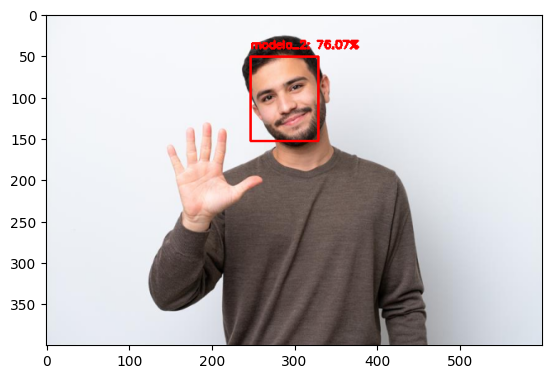

In [13]:
########################
## Processar o Modelo ##
########################

# Define a image de teste
image_to_test_path = "test/modelo_2_1.jpeg"

# Carrega os modelos
protoPath = os.path.sep.join(["face_detection_model", "deploy.prototxt"])
modelPath = os.path.sep.join(["face_detection_model",
    "res10_300x300_ssd_iter_140000.caffemodel"])
detector = cv2.dnn.readNetFromCaffe(protoPath, modelPath)

embedder = cv2.dnn.readNetFromTorch("openface_nn4.small2.v1.t7")
recognizer = pickle.loads(open("output/recognizer.pickle", "rb").read())
le = pickle.loads(open("output/le.pickle", "rb").read())

# Carrega a imagem
image = cv2.imread(image_to_test_path)
image = imutils.resize(image, width=600)
(h, w) = image.shape[:2]
imageBlob = cv2.dnn.blobFromImage(
    cv2.resize(image, (300, 300)), 1.0, (300, 300),
    (104.0, 177.0, 123.0), swapRB=False, crop=False)
detector.setInput(imageBlob)
detections = detector.forward()

for i in range(0, detections.shape[2]):
    confidence = detections[0, 0, i, 2]
    if confidence > 0.5:
        box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
        (startX, startY, endX, endY) = box.astype("int")
        face = image[startY:endY, startX:endX]
        (fH, fW) = face.shape[:2]
        if fW < 20 or fH < 20:
            continue
        
        faceBlob = cv2.dnn.blobFromImage(face, 1.0 / 255,
            (96, 96), (0, 0, 0), swapRB=True, crop=False)
        embedder.setInput(faceBlob)
        vec = embedder.forward()
        
        preds = recognizer.predict_proba(vec)[0]
        j = np.argmax(preds)
        proba = preds[j]
        name = le.classes_[j]
        
        text = "{}: {:.2f}%".format(name, proba * 100)
        y = startY - 10 if startY - 10 > 10 else startY + 10
        cv2.rectangle(image, (startX, startY), (endX, endY),
            (0, 0, 255), 2)
        cv2.putText(image, text, (startX, y),
            cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 255), 2)

# mostra a imagem
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

### Referência

- https://pyimagesearch.com/2018/09/24/opencv-face-recognition/
- https://pyimagesearch.com/2018/06/18/face-recognition-with-opencv-python-and-deep-learning/